In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

1. DATA UNDERSTANDING


In [2]:
df = pd.read_csv('/content/full_grouped.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/full_grouped.csv'

In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(35156, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            35156 non-null  object
 1   Country/Region  35156 non-null  object
 2   Confirmed       35156 non-null  int64 
 3   Deaths          35156 non-null  int64 
 4   Recovered       35156 non-null  int64 
 5   Active          35156 non-null  int64 
 6   New cases       35156 non-null  int64 
 7   New deaths      35156 non-null  int64 
 8   New recovered   35156 non-null  int64 
 9   WHO Region      35156 non-null  object
dtypes: int64(7), object(3)
memory usage: 2.7+ MB
None
          Confirmed         Deaths     Recovered        Active    New cases  \
count  3.515600e+04   35156.000000  3.515600e+04  3.515600e+04  35156.00000   
mean   2.356663e+04    1234.068239  1.104813e+04  1.128443e+04    469.36375   
std    1.499818e+05    7437.238354  6.454640e+04  8.997149e

2. DATA PREPROCESSING


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

df.drop('Date', axis=1, inplace=True)

In [ ]:
le = LabelEncoder()
df['Country/Region'] = le.fit_transform(df['Country/Region'])

In [ ]:
df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)

In [ ]:
X = df.drop('Confirmed', axis=1)
y = df['Confirmed']

In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

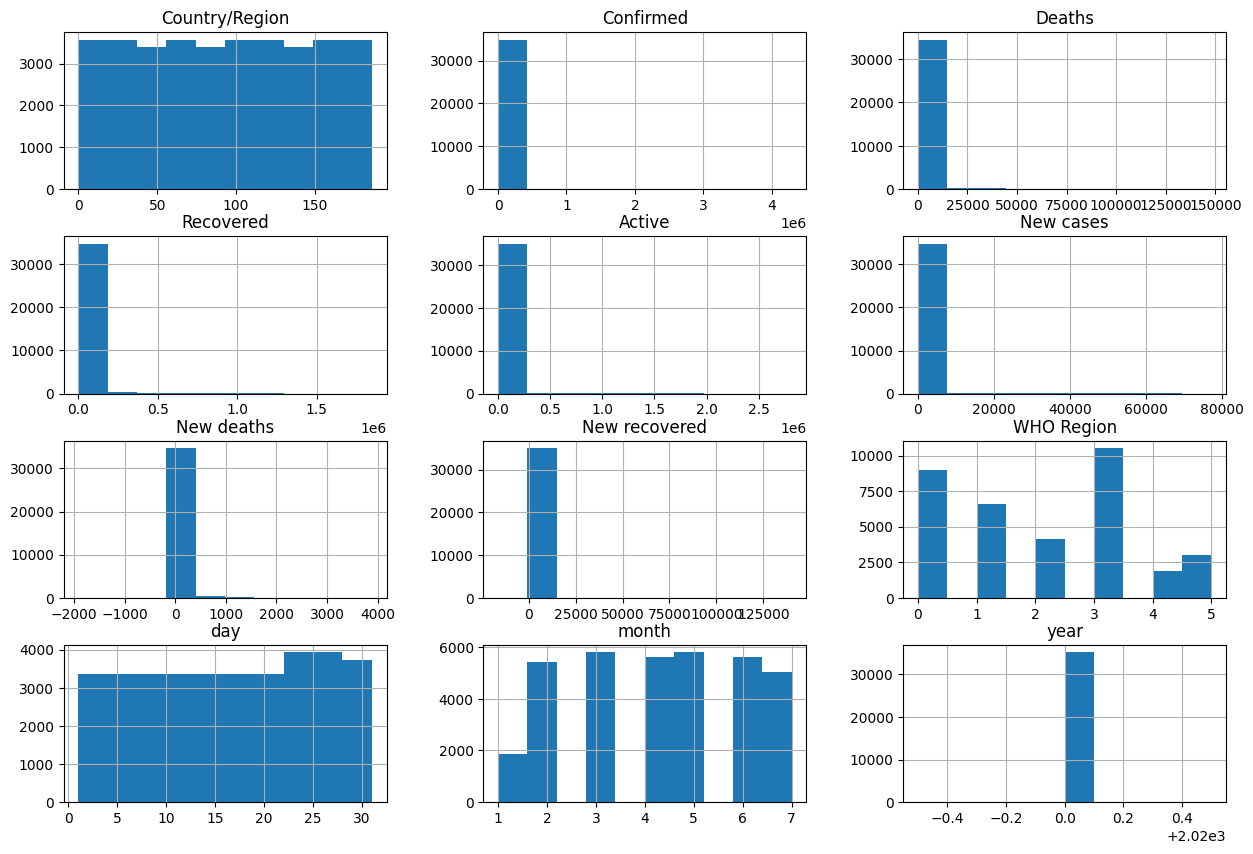

In [ ]:
df.hist(figsize=(15,10))
plt.show()

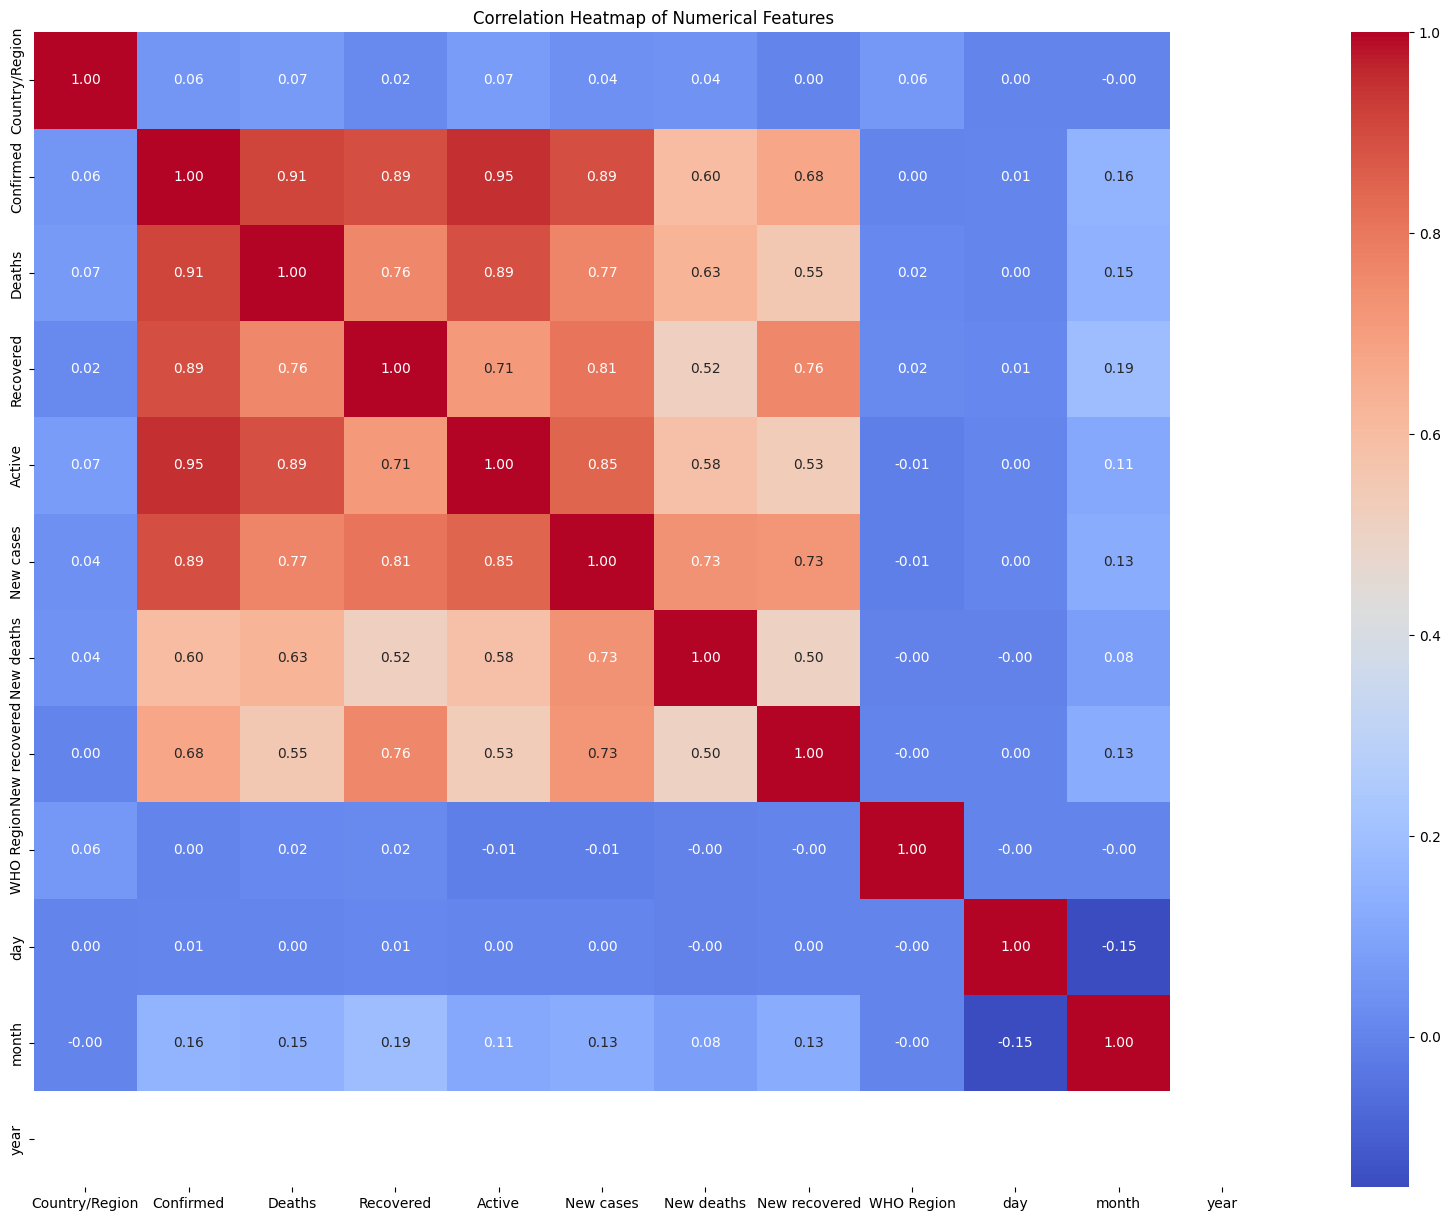

In [ ]:
# Select only numerical columns for correlation calculation
numerical_data = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()

# Plotting the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
print(df.corr()['Confirmed'].sort_values(ascending=False))

Confirmed         1.000000
Active            0.949940
Deaths            0.912016
Recovered         0.894418
New cases         0.893966
New recovered     0.675623
New deaths        0.602815
month             0.155134
Country/Region    0.055704
day               0.006847
WHO Region        0.002810
year                   NaN
Name: Confirmed, dtype: float64


In [ ]:
splits = {
    "70:30": train_test_split(X_scaled, y, test_size=0.3, random_state=42),
    "80:20": train_test_split(X_scaled, y, test_size=0.2, random_state=42),
    "90:10": train_test_split(X_scaled, y, test_size=0.1, random_state=42)
}

In [ ]:
lr = LinearRegression()

In [ ]:
dt = DecisionTreeRegressor()

param_dt = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(dt, param_dt, cv=5)

In [ ]:
rf = RandomForestRegressor()

param_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rand_rf = RandomizedSearchCV(rf, param_rf, n_iter=5, cv=5)

In [ ]:
results = []

def evaluate(split, model_name, y_test, pred):
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    results.append([split, model_name, mae, mse, rmse, r2])

for name, (X_train, X_test, y_train, y_test) in splits.items():

    # LR
    lr.fit(X_train, y_train)
    evaluate(name, "Linear Regression", y_test, lr.predict(X_test))

    # DT
    grid_dt.fit(X_train, y_train)
    evaluate(name, "Decision Tree", y_test, grid_dt.predict(X_test))

    # RF
    rand_rf.fit(X_train, y_train)
    evaluate(name, "Random Forest", y_test, rand_rf.predict(X_test))

In [ ]:
results_df = pd.DataFrame(results, columns=[
    'Split', 'Model', 'MAE', 'MSE', 'RMSE', 'R2'
])

print(results_df)

   Split              Model           MAE           MSE          RMSE  \
0  70:30  Linear Regression  5.283106e-11  7.905668e-21  8.891382e-11   
1  70:30      Decision Tree  5.752658e+02  2.127783e+07  4.612790e+03   
2  70:30      Random Forest  3.153692e+02  7.784315e+06  2.790039e+03   
3  80:20  Linear Regression  6.098659e-11  2.300910e-20  1.516875e-10   
4  80:20      Decision Tree  9.005603e+02  1.849879e+07  4.301023e+03   
5  80:20      Random Forest  2.998769e+02  7.786189e+06  2.790374e+03   
6  90:10  Linear Regression  4.538782e-11  6.234233e-21  7.895716e-11   
7  90:10      Decision Tree  6.249759e+02  3.435895e+07  5.861650e+03   
8  90:10      Random Forest  2.837723e+02  7.920741e+06  2.814381e+03   

         R2  
0  1.000000  
1  0.998641  
2  0.999503  
3  1.000000  
4  0.999043  
5  0.999597  
6  1.000000  
7  0.998654  
8  0.999690  


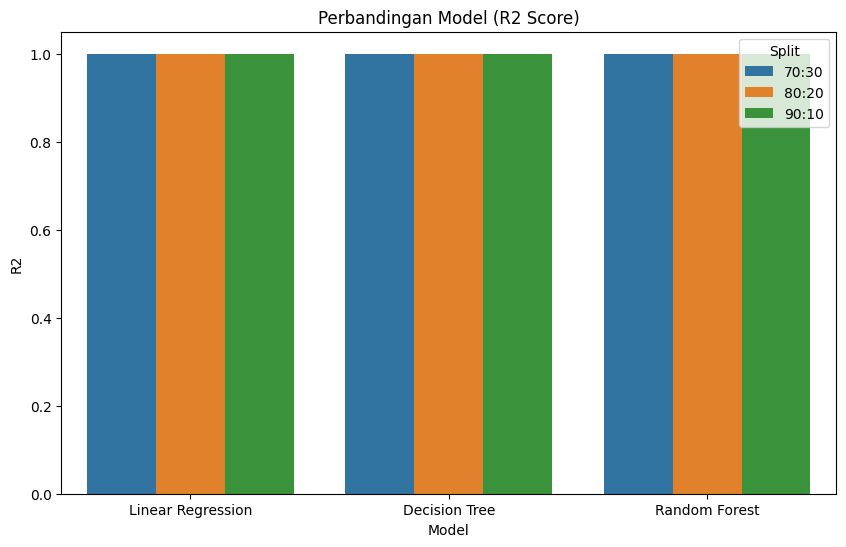

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='Model', y='R2', hue='Split')
plt.title('Perbandingan Model (R2 Score)')
plt.show()

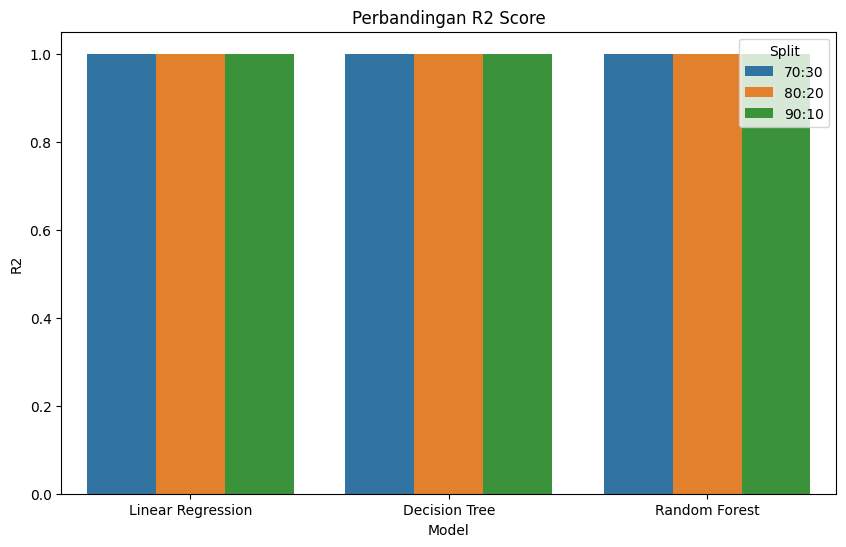

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='Model', y='R2', hue='Split')
plt.title('Perbandingan R2 Score')
plt.show()